# Basis Trading Strategy

In [1]:

# Data handling
import requests
import pandas as pd
import numpy as np
import datetime

# Plotting
import matplotlib.pyplot as plt
import warnings

# Statistical Models and Tests
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tools.sm_exceptions import InterpolationWarning

warnings.filterwarnings('ignore', category=InterpolationWarning)

In [11]:
coin = pd.read_csv('data/Price/btc-usdt-binance.csv')
perp = pd.read_csv('data/Price/btc-usdt-perp-binance.csv')
fr = pd.read_csv('data/Funding Rate/btc-perp-fr.csv')

In [14]:
perp.keys()

Index(['UNIT', 'TIMESTAMP', 'TYPE', 'MARKET', 'INSTRUMENT', 'OPEN', 'HIGH',
       'LOW', 'CLOSE', 'FIRST_TRADE_TIMESTAMP', 'LAST_TRADE_TIMESTAMP',
       'FIRST_TRADE_PRICE', 'HIGH_TRADE_PRICE', 'HIGH_TRADE_TIMESTAMP',
       'LOW_TRADE_PRICE', 'LOW_TRADE_TIMESTAMP', 'LAST_TRADE_PRICE',
       'TOTAL_TRADES', 'TOTAL_TRADES_BUY', 'TOTAL_TRADES_SELL',
       'TOTAL_TRADES_UNKNOWN', 'NUMBER_OF_CONTRACTS', 'VOLUME', 'QUOTE_VOLUME',
       'VOLUME_BUY', 'QUOTE_VOLUME_BUY', 'VOLUME_SELL', 'QUOTE_VOLUME_SELL',
       'VOLUME_UNKNOWN', 'QUOTE_VOLUME_UNKNOWN'],
      dtype='object')

In [13]:
coin.keys()

Index(['UNIT', 'TIMESTAMP', 'TYPE', 'MARKET', 'INSTRUMENT', 'OPEN', 'HIGH',
       'LOW', 'CLOSE', 'FIRST_TRADE_TIMESTAMP', 'LAST_TRADE_TIMESTAMP',
       'FIRST_TRADE_PRICE', 'HIGH_TRADE_PRICE', 'HIGH_TRADE_TIMESTAMP',
       'LOW_TRADE_PRICE', 'LOW_TRADE_TIMESTAMP', 'LAST_TRADE_PRICE',
       'TOTAL_TRADES', 'TOTAL_TRADES_BUY', 'TOTAL_TRADES_SELL',
       'TOTAL_TRADES_UNKNOWN', 'VOLUME', 'QUOTE_VOLUME', 'VOLUME_BUY',
       'QUOTE_VOLUME_BUY', 'VOLUME_SELL', 'QUOTE_VOLUME_SELL',
       'VOLUME_UNKNOWN', 'QUOTE_VOLUME_UNKNOWN'],
      dtype='object')

In [15]:
coin.head()

,UNIT,TIMESTAMP,TYPE,MARKET,INSTRUMENT,OPEN,HIGH,LOW,CLOSE,FIRST_TRADE_TIMESTAMP,...,TOTAL_TRADES_SELL,TOTAL_TRADES_UNKNOWN,VOLUME,QUOTE_VOLUME,VOLUME_BUY,QUOTE_VOLUME_BUY,VOLUME_SELL,QUOTE_VOLUME_SELL,VOLUME_UNKNOWN,QUOTE_VOLUME_UNKNOWN
0,HOUR,2024-10-17 09:00:00,707,binance,BTCUSDT,67450.00,67530.01,67185.16,67191.40,1729155600,...,74789,0,941.84050,6.344260e+07,309.60799,2.086117e+07,632.23251,4.258142e+07,0,0
1,HOUR,2024-10-17 10:00:00,707,binance,BTCUSDT,67191.40,67295.40,66818.96,67214.00,1729159200,...,95476,0,1208.73503,8.107840e+07,581.58445,3.901551e+07,627.15058,4.206290e+07,0,0
2,HOUR,2024-10-17 11:00:00,707,binance,BTCUSDT,67214.00,67285.00,66741.09,66872.43,1729162800,...,151828,0,1944.76935,1.301598e+08,684.83452,4.583364e+07,1259.93483,8.432620e+07,0,0
3,HOUR,2024-10-17 12:00:00,707,binance,BTCUSDT,66872.43,67184.00,66799.90,67171.42,1729166400,...,121912,0,998.62443,6.693451e+07,544.50415,3.649605e+07,454.12028,3.043846e+07,0,0
4,HOUR,2024-10-17 13:00:00,707,binance,BTCUSDT,67171.42,67354.94,66669.00,67021.99,1729170000,...,180169,0,1702.17377,1.141063e+08,892.28318,5.982669e+07,809.89059,5.427958e+07,0,0


In [17]:
coin = coin[['TIMESTAMP', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME_SELL', 'VOLUME_BUY', 'VOLUME']]
perp = perp[['TIMESTAMP', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'VOLUME_SELL', 'VOLUME_BUY', 'VOLUME']]
fr = fr[['TIMESTAMP', 'OPEN', 'HIGH', 'LOW', 'CLOSE']]

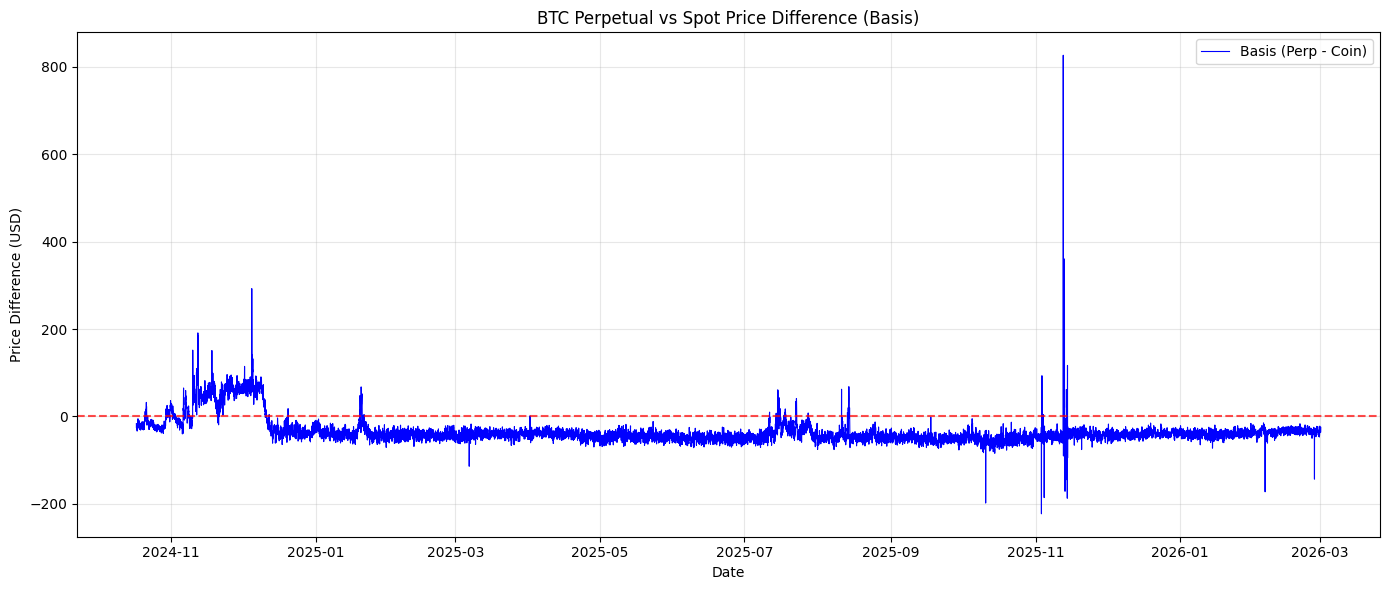

In [20]:
# Convert TIMESTAMPs to datetime
coin['TIMESTAMP'] = pd.to_datetime(coin['TIMESTAMP'])
perp['TIMESTAMP'] = pd.to_datetime(perp['TIMESTAMP'])

# Merge on TIMESTAMP
merged = pd.merge(coin, perp, on='TIMESTAMP', suffixes=('_coin', '_perp'))

# Calculate the price difference (basis)
merged['basis'] = merged['CLOSE_perp'] - merged['CLOSE_coin']

# Plot the basis
plt.figure(figsize=(14, 6))
plt.plot(merged['TIMESTAMP'], merged['basis'], label='Basis (Perp - Coin)', color='blue', linewidth=0.8)
plt.axhline(y=0, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price Difference (USD)')
plt.title('BTC Perpetual vs Spot Price Difference (Basis)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()